In [5]:
import numpy as np
import os

data_files = [f for f in os.listdir("raw/") if f.endswith(".npz")]
data = []
for file in data_files:
    data.append(np.load(os.path.join("raw/", file)))
num_demos = len(data)

In [6]:
max_abs = -100
for k in range(num_demos):
    max_abs = max(max_abs, np.max(np.abs(data[k]['actions'])))

print(max_abs)

0.006575027


In [7]:
t_steps = data[0]['actions'].shape[0]

num_train, num_test = 4*num_demos//5,num_demos//5
dy = data[0]['actions'].shape[1]

x, y, g, x_test, y_test, g_test = [], [], [], [], [], []


for k in range(num_demos):
    if data[k]['g'] in g_test:
        x.append(data[k]['x'])
        y.append(data[k]['actions']/max_abs)
        g.append(data[k]['g'])
    else:
        x_test.append(data[k]['x'])
        y_test.append(data[k]['actions']/max_abs)
        g_test.append(data[k]['g'])

x = np.array(x, dtype=np.float32)
y = np.array(y, dtype=np.float32)
g = np.array(g, dtype=np.float32)
x_test = np.array(x_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)
g_test = np.array(g_test, dtype=np.float32)

# Save these as .npy files
np.save("processed/x.npy", x)
np.save("processed/y.npy", y)
np.save("processed/g.npy", g)
np.save("processed/x_test.npy", x_test)
np.save("processed/y_test.npy", y_test)
np.save("processed/g_test.npy", g_test)

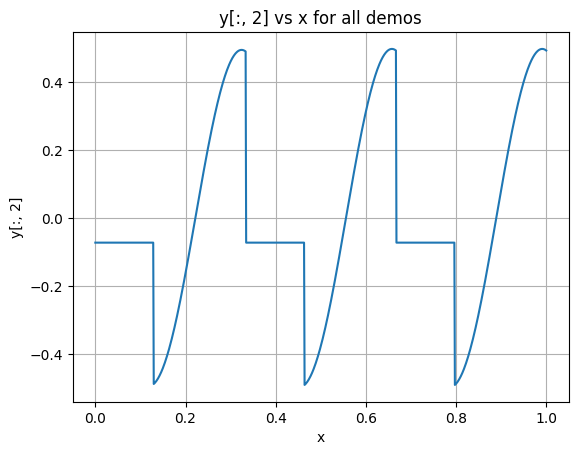

In [18]:
# For a given d, plot y[i, d]-x[i] graph

d = 2
import matplotlib.pyplot as plt
for i in range(3,4):
    plt.plot(x[i], y[i, :, d], label=f"Demo {i}")

plt.xlabel("x")
plt.ylabel(f"y[:, {d}]")
plt.grid()
plt.title(f"y[:, {d}] vs x for all demos")
# plt.legend()
plt.show()
